# Project 4 – Data Visualization

### Prepared by
**[Julian Andres Belmonte Ortiz](https://www.linkedin.com/in/julianbel/)**

### Organization
DecodeLabs – Training Program 2026

---

## Project Objective

The objective of this project is to transform raw sales data into meaningful visual insights through the use of data visualization techniques. By creating charts and graphical representations, the project aims to identify trends, compare categories, and communicate key findings in a clear and engaging manner.

The analysis will utilize different types of visualizations, including bar charts, line charts, pie charts, and other appropriate graphical formats, to explore sales performance, customer behavior, product demand, and business metrics. Each visualization will be designed to highlight important patterns and support data driven decision making.

Through this project, essential skills in data visualization, storytelling with data, and analytical interpretation will be developed, demonstrating the ability to convert complex datasets into actionable business insights.


# Import Libraries

In [35]:
# ============================================================
# PROJECT 4 - DATA VISUALIZATION
#
# This project focuses on transforming raw sales data
# into visual insights using charts and graphs.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Improve chart appearance

plt.style.use('default')
sns.set_theme()

# Load Dataset

In [36]:
# Load the Excel dataset

df = pd.read_excel('Cleaned_Dataset_Project1.xlsx')

# Display first rows

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


# Data Overview

In [37]:
# Basic dataset information

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(1200, 15)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'CalculatedTotal']

Missing Values:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
CalculatedTotal    0
dtype: int64


# Data Preparation

In [38]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

# Create Year-Month column for trend analysis

df['YearMonth'] = df['Date'].dt.to_period('M')

# Visualization 1: Revenue by Product

Business Question

Which products generate the highest revenue?

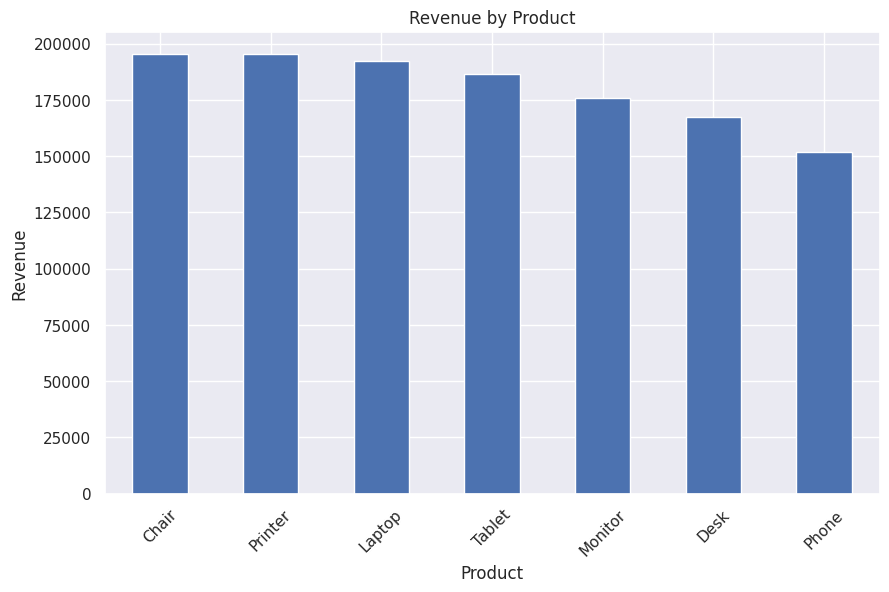

In [39]:
# Aggregate revenue by product

product_sales = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

product_sales.plot(kind='bar')

plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

Products with the highest revenue contribute the most to overall business performance and should be prioritized in sales and marketing strategies.

### Business Insight for Revenue by Product:

This visualization highlights the **top performing products** that contribute most significantly to overall revenue. For a business, this is crucial for:

*   **Strategic Prioritization**: Allocate more resources (marketing budget, inventory, sales focus) to these high revenue products.
*   **Inventory Management**: Ensure consistent availability of these popular items to avoid stockouts and lost sales.
*   **Product Development**: Analyze the characteristics and customer appeal of these successful products to inform future product design and offerings.
*   **Cross-selling/Up-selling**: Develop strategies to pair these popular products with complementary items or premium versions.

Identifying these key drivers allows the business to make data backed decisions on resource allocation and product strategy, maximizing profitability.

# Visualization 2: Order Status Distribution

Business Question

How are orders distributed across different statuses?

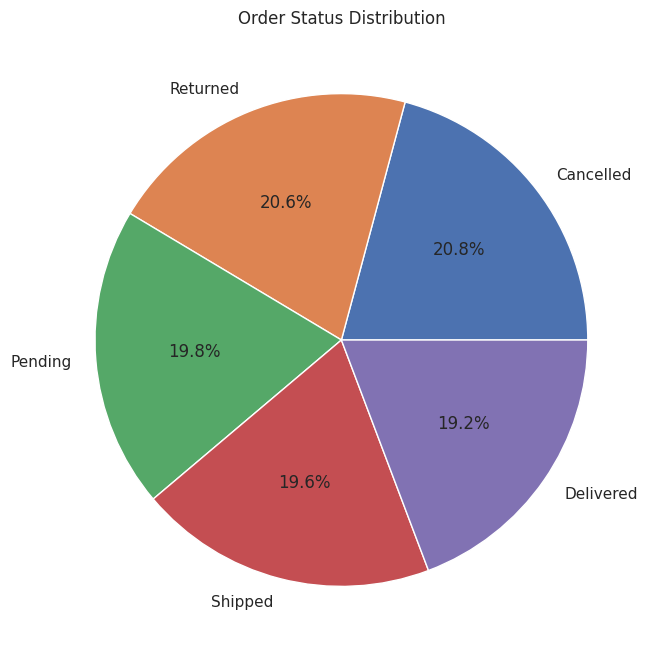

In [40]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title('Order Status Distribution')

plt.show()

The chart helps evaluate operational efficiency by showing the proportion of delivered, shipped, cancelled, and returned orders.

### Business Insight for Order Status Distribution:

Understanding the distribution of order statuses is vital for **operational efficiency and customer satisfaction**. This pie chart provides insights into:

*   **Process Bottlenecks**: A high percentage of 'Pending' orders might indicate a bottleneck in order processing or fulfillment.
*   **Customer Experience Issues**: High 'Cancelled' or 'Returned' rates could point to problems with product quality, inaccurate descriptions, lengthy delivery times, or a difficult purchasing process. Each cancelled or returned order represents a lost sale and potentially a dissatisfied customer.
*   **Operational Health**: The proportion of 'Delivered' orders is a direct measure of successful transactions. Monitoring trends in these statuses helps in promptly identifying and addressing operational weaknesses, improving customer trust, and reducing costs associated with returns and cancellations.

# Visualization 3: Monthly Revenue Trend

Business Question

How does revenue change over time?

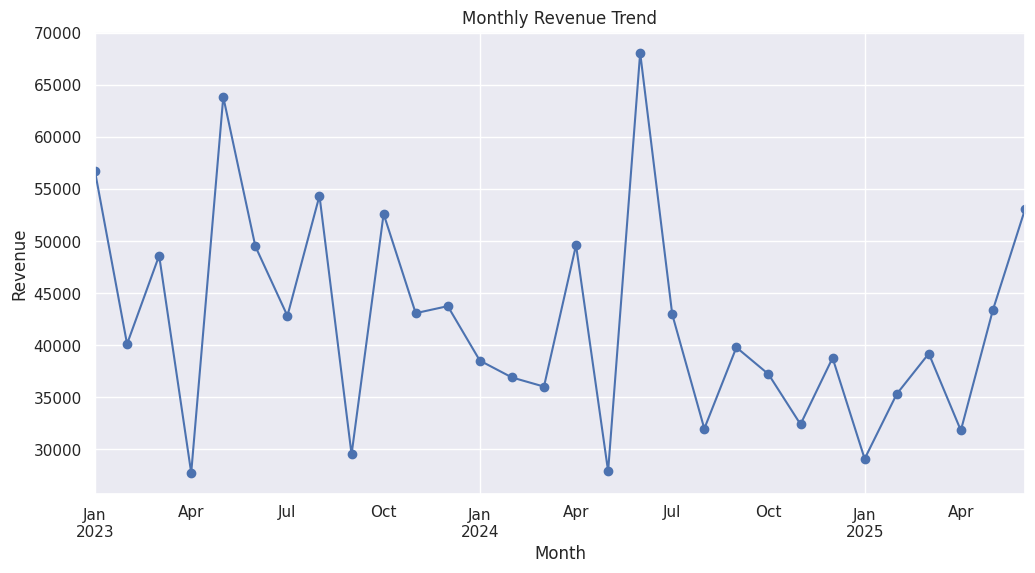

In [30]:
monthly_sales = (
    df.groupby('YearMonth')['TotalPrice']
    .sum()
)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

The line chart highlights sales trends over time and helps identify growth periods or seasonal patterns.

### Business Insight for Monthly Revenue Trend:

This line chart is a cornerstone for **financial planning and strategic forecasting**. Analyzing the monthly revenue trend reveals:

*   **Seasonal Patterns**: Identify recurring peaks and troughs in sales, allowing the business to anticipate demand fluctuations. This is critical for optimizing staffing, inventory levels, and marketing campaigns.
*   **Growth Trajectories**: Determine if the business is experiencing consistent growth, stagnation, or decline over time.
*   **Impact of Initiatives**: Evaluate the effectiveness of past marketing campaigns, product launches, or pricing changes by observing corresponding changes in revenue.

These insights enable proactive decision making, such as adjusting marketing spend, planning promotions during slow periods, or expanding production capacity during peak seasons, leading to more robust financial health.

# Visualization 4: Revenue by Payment Method

Business Question

Which payment methods generate the most revenue?

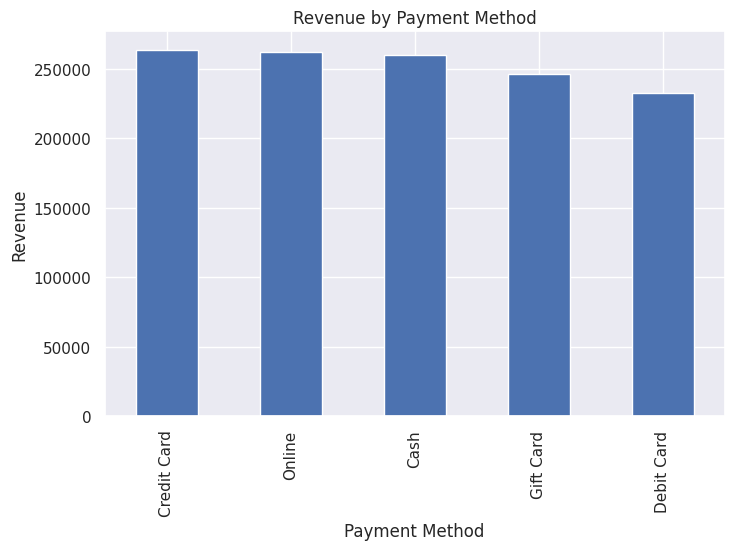

In [31]:
payment_sales = (
    df.groupby('PaymentMethod')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

payment_sales.plot(kind='bar')

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')

plt.show()

Understanding customer payment preferences can help improve checkout experiences and optimize payment options.

### Business Insight for Revenue by Payment Method:

This visualization provides valuable information about **customer payment preferences**, which can inform strategic decisions related to the checkout experience and financial operations:

*   **Payment Gateway Optimization**: Identify the most frequently used payment methods (e.g., Credit Card, Online Payment). Ensure these methods are seamlessly integrated, secure, and reliable to minimize friction during checkout.
*   **Cost Management**: Different payment methods may incur varying transaction fees. Understanding which methods drive the most revenue allows the business to negotiate better terms with providers or explore more cost effective alternatives for less popular options.
*   **Customer Convenience**: Offering preferred payment options improves customer experience and can reduce cart abandonment rates.

By catering to customer preferences, the business can enhance conversion rates and streamline financial processes.

# Visualization 5: Revenue by Referral Source

Business Question

Which marketing channels bring the most revenue?

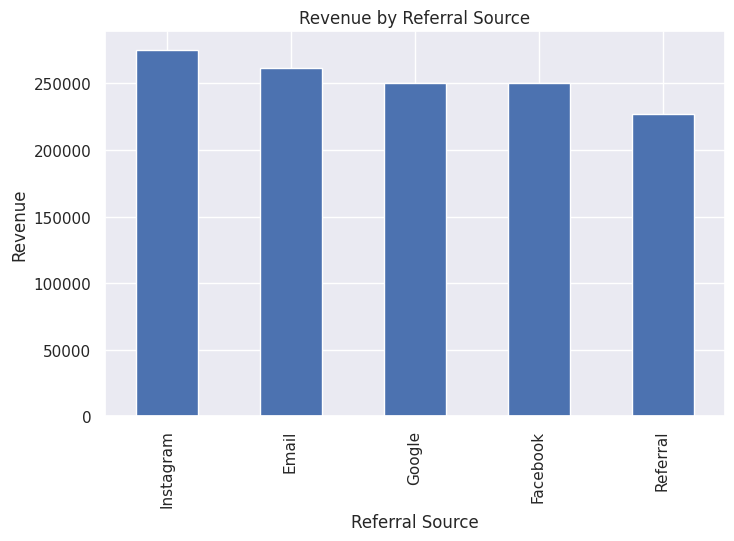

In [32]:
referral_sales = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

referral_sales.plot(kind='bar')

plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Revenue')

plt.show()

The chart shows which acquisition channels are driving the highest revenue and can guide future marketing investments.

### Business Insight for Revenue by Referral Source:

This bar chart is essential for **optimizing marketing spend and strategy**. It directly answers which marketing channels are most effective in generating revenue:

*   **ROI Measurement**: Calculate the Return on Investment (ROI) for each referral source. This allows for a data driven approach to marketing budget allocation, focusing investments on channels that deliver the highest revenue.
*   **Channel Effectiveness**: Identify which platforms (e.g., Instagram, Email, Google) are successfully attracting customers who convert into sales. This can guide content strategy and audience targeting.
*   **Underperforming Channels**: Pinpoint channels that yield low revenue, prompting an investigation into their strategy, targeting, or whether to reallocate resources elsewhere.

Understanding which channels are most profitable helps the business acquire customers more efficiently and maximize its marketing impact.

# Visualization 6: Quantity Distribution

Business Question

How many units are typically purchased per order?

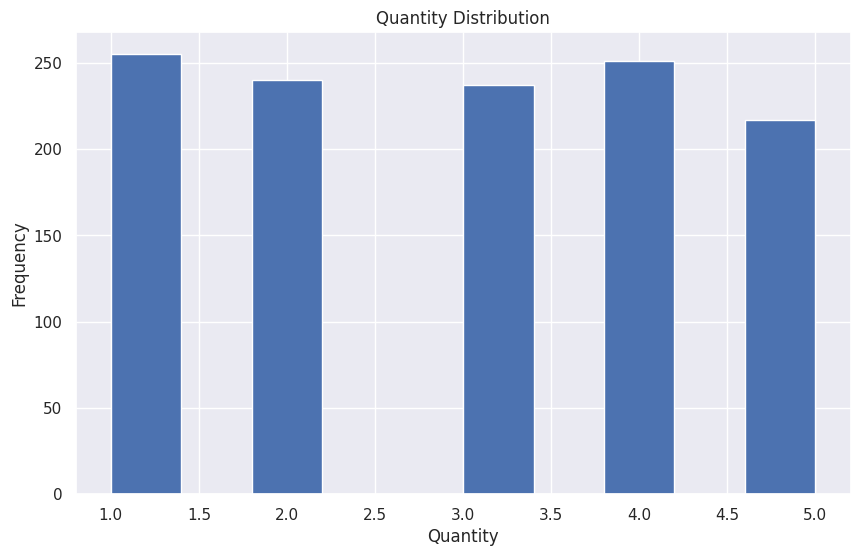

In [33]:
plt.figure(figsize=(10,6))

plt.hist(df['Quantity'], bins=10)

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

This distribution helps identify common purchasing patterns and potential outliers.

### Business Insight for Quantity Distribution:

The distribution of purchase quantities offers insights into **customer buying behavior and inventory planning**:

*   **Sales Strategy**: If customers typically buy small quantities (e.g., 1-2 items), the business might consider implementing strategies like 'buy one, get one free,' bundle deals, or quantity discounts to encourage larger purchases.
*   **Inventory Management**: Anticipate typical order sizes to optimize stock levels and warehouse operations. This helps prevent overstocking of certain items or frequent stockouts of others.
*   **Packaging and Logistics**: Understanding common purchase quantities can also influence packaging strategies and shipping costs.

This analysis helps in fine tuning sales promotions and ensuring that operational aspects align with customer purchasing habits.

# Visualization 7: Top 10 Orders by Revenue

Business Question

Which orders generated the highest revenue?

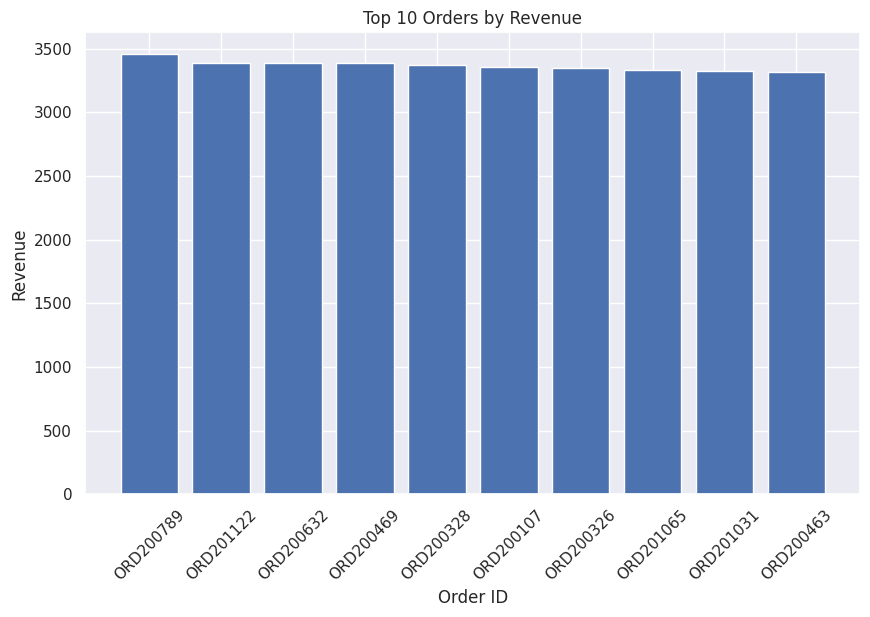

In [34]:
top_orders = (
    df[['OrderID', 'TotalPrice']]
    .sort_values('TotalPrice', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(top_orders['OrderID'], top_orders['TotalPrice'])

plt.title('Top 10 Orders by Revenue')
plt.xlabel('Order ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

Identifying top-performing transactions helps understand high value customer behavior.

### Business Insight for Top 10 Orders by Revenue:

Analyzing the top 10 orders by revenue allows the business to identify **high-value transactions and customer segments**:

*   **Customer Profiling**: Investigate the characteristics of customers who place these large orders. This can include their demographics, purchase history, and common products, which can inform the creation of target profiles for high value customers.
*   **Product Bundling/Premium Offerings**: Determine if specific products or combinations of products are frequently part of these large orders, suggesting opportunities for curated bundles or premium packages.
*   **Customer Relationship Management (CRM)**: Identify opportunities to cultivate relationships with these high spending customers through loyalty programs, personalized offers, or dedicated support.

Focusing on these top transactions provides valuable clues about what drives significant revenue and how to replicate such successes, leading to increased customer lifetime value.

# Key Findings

1.  **Product Performance**: Products like 'Chair', 'Printer', and 'Laptop' are significant revenue drivers, generating the highest sales, highlighting their importance in the product portfolio.

2.  **Revenue Trends**: The monthly revenue trend demonstrates fluctuations over time, indicating periods of higher and lower sales that are crucial for understanding business cycles and planning.

3.  **Payment Preferences**: 'Credit Card', 'Online', and 'Cash' are the most preferred payment methods, contributing the largest share of total revenue, which should inform payment processing strategies.

4.  **Marketing Channel Effectiveness**: 'Instagram', 'Email', and 'Google' are the leading referral sources, proving to be the most effective marketing channels for driving revenue and customer acquisition.

5.  **Operational Efficiency**: The order status distribution reveals a notable proportion of 'Cancelled' and 'Returned' orders, indicating potential areas for operational improvement and customer experience enhancement.

6.  **Purchase Behavior**: The quantity distribution typically shows that customers frequently purchase 1-2 items per order, offering insights for sales promotions and inventory management.

7.  **Data-Driven Decisions**: The project successfully demonstrated that data visualization is an effective tool for quickly understanding complex business performance and facilitating data driven decision making.